# Análisis de Caso: Técnicas de Reducción Dimensional

**Empresa:** DataMed Analytics  

**Rol asumido:** Científico de Datos Junior del equipo de IA  

**Autor:** Manuel Quintana  

**Curso:** Fundamentos de Ciencia de Datos  

**Dataset:** Human Activity Recognition (HAR) Dataset  

**Herramientas:** Python, NumPy, Pandas, Scikit-Learn, Matplotlib, PCA, t-SNE  

**Objetivo del análisis:**  
Aplicar técnicas de reducción dimensional (PCA y t-SNE) sobre un dataset de alta dimensionalidad, con el fin de simplificar su estructura, analizar la varianza explicada, identificar patrones en los datos y evaluar su utilidad en la visualización y en el apoyo a modelos predictivos.

## Objetivo

Aplicar técnicas de reducción de dimensionalidad, específicamente PCA y t-SNE, sobre un conjunto de datos de alta dimensionalidad, con el fin de simplificar su estructura, analizar la varianza explicada por los componentes principales, identificar patrones y posibles agrupaciones en los datos, y evaluar su utilidad tanto para la visualización como para su integración en procesos de modelado predictivo.

## 1. Importación de librerías

In [22]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Escalamiento de datos
from sklearn.preprocessing import StandardScaler

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configuración de gráficos
plt.style.use('seaborn-v0_8')

## 2. Carga del conjunto de datos

En esta sección se carga el dataset *Human Activity Recognition (HAR)*, el cual contiene múltiples variables numéricas obtenidas a partir de sensores de teléfonos inteligentes. Este conjunto de datos se caracteriza por su alta dimensionalidad, con una gran cantidad de características (features), lo que lo convierte en un caso adecuado para la aplicación de técnicas de reducción dimensional.

El objetivo de trabajar con este dataset es analizar cómo métodos como PCA y t-SNE permiten simplificar la estructura de los datos, evaluar la varianza explicada por los componentes principales, identificar patrones y agrupaciones, y facilitar tanto la visualización como su posible uso en modelos predictivos.

Fuente del dataset:  
https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

In [23]:
# Cargar datos (features)
data = pd.read_csv("X_train.txt", sep="\s+", header=None)

# Cargar etiquetas (números del 1 al 6)
y = pd.read_csv("y_train.txt", header=None)

# Cargar nombres de actividades
activity_labels = pd.read_csv("activity_labels.txt", sep=" ", header=None)
activity_labels.columns = ["id", "activity"]

# Reemplazar números por nombres
y = y[0].map(dict(activity_labels.values))

# Ver dimensiones
print(f"Dimensiones del dataset: {data.shape}")
print(f"Dimensiones de etiquetas: {y.shape}")

# Vista previa
display(data.head())
display(y.head())

Dimensiones del dataset: (7352, 561)
Dimensiones de etiquetas: (7352,)


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: 0, dtype: str

## 3. Escalamiento de datos

Se aplica StandardScaler para estandarizar las variables, transformando los datos de modo que tengan media 0 y desviación estándar 1. Este paso es fundamental para técnicas como PCA y t-SNE, ya que ambas son sensibles a la escala de las variables.

In [24]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Datos escalados correctamente")

Datos escalados correctamente


## 4. PCA

Se aplica el método de Análisis de Componentes Principales (PCA) con el objetivo de reducir la dimensionalidad del dataset, preservando la mayor cantidad posible de información.

A través del análisis de la varianza explicada acumulada, es posible determinar cuántos componentes son necesarios para representar adecuadamente los datos. Este análisis permite identificar un número óptimo de componentes que capture la mayor proporción de la variabilidad, reduciendo así la complejidad del dataset sin perder información relevante.

In [25]:
pca = PCA()
pca.fit(data_scaled)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)


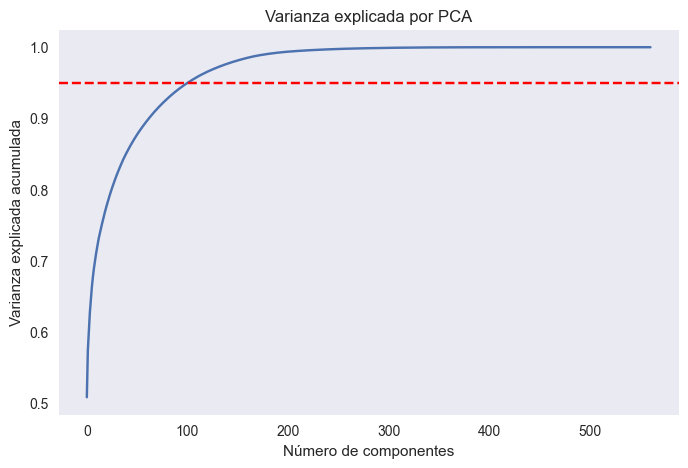

In [26]:

plt.figure(figsize=(8,5))
plt.plot(varianza_acumulada)

# Línea de referencia para 95% de varianza
plt.axhline(y=0.95, color='r', linestyle='--')

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada por PCA")
plt.grid()
plt.show()

A partir del gráfico de varianza explicada acumulada, se observa que la mayor parte de la información del dataset se concentra en los primeros componentes principales.

La inclusión de una línea de referencia en el 95% permite identificar que aproximadamente entre 100 y 120 componentes son suficientes para explicar la mayor parte de la varianza del dataset.

A partir de este punto, la curva se estabiliza, indicando que agregar más componentes aporta un beneficio marginal en la representación de los datos.

Por lo tanto, se puede concluir que una reducción a aproximadamente 100–120 componentes permite mantener la mayor parte de la información, reduciendo significativamente la dimensionalidad del dataset.

## 5. t-SNE

Se aplica el método t-SNE (t-Distributed Stochastic Neighbor Embedding) con el objetivo de visualizar la estructura de los datos en un espacio de menor dimensión, preservando las relaciones locales entre las observaciones.

A diferencia de PCA, t-SNE es un método no lineal, lo que le permite capturar patrones complejos y revelar agrupaciones que no son visibles mediante técnicas lineales.

Para su aplicación, se definen parámetros como perplexity, que controla el equilibrio entre la estructura local y global de los datos, y random_state para asegurar la reproducibilidad de los resultados.

In [27]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
data_tsne = tsne.fit_transform(data_scaled)

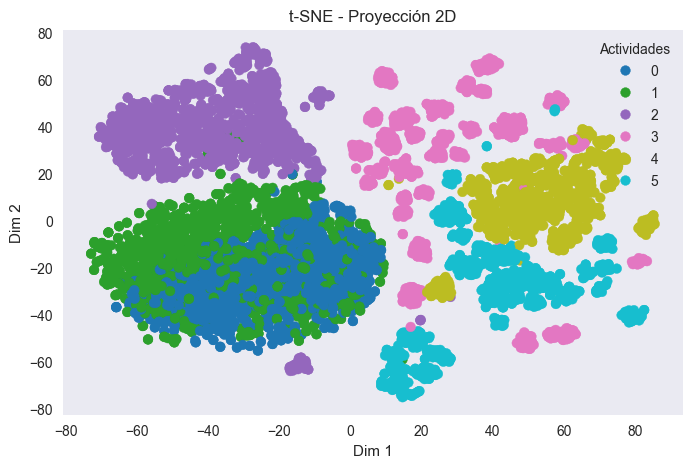

In [28]:
plt.figure(figsize=(8,5))
scatter = plt.scatter(data_tsne[:,0], data_tsne[:,1], 
                      c=pd.factorize(y)[0], cmap='tab10')

plt.title("t-SNE - Proyección 2D")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

# Leyenda
plt.legend(*scatter.legend_elements(), title="Actividades")

plt.grid()
plt.show()

El gráfico obtenido mediante t-SNE muestra una clara formación de agrupaciones en los datos, donde cada color representa una actividad distinta.

A diferencia de PCA, t-SNE logra separar de manera más evidente los distintos grupos, lo que indica que es capaz de capturar relaciones no lineales entre las variables.

Se observan clusters bien definidos, especialmente en la parte derecha del gráfico, mientras que en la zona izquierda existe cierto solapamiento entre algunos grupos, lo que sugiere similitudes entre ciertas actividades.

En general, t-SNE permite una visualización más clara de la estructura interna del dataset, facilitando la identificación de patrones y agrupaciones.

Las etiquetas numéricas corresponden a las siguientes actividades:

- 0 → STANDING  
- 1 → SITTING  
- 2 → LAYING  
- 3 → WALKING  
- 4 → WALKING_DOWNSTAIRS  
- 5 → WALKING_UPSTAIRS 

## 6. Comparación entre PCA y t-SNE

En esta sección se comparan los resultados obtenidos mediante PCA y t-SNE, con el objetivo de evaluar cuál técnica es más adecuada para el análisis y visualización del dataset.

PCA es un método lineal que busca proyectar los datos en un espacio de menor dimensión maximizando la varianza explicada. Esto permite reducir la dimensionalidad manteniendo la mayor cantidad de información posible, siendo especialmente útil como paso previo para modelos de aprendizaje automático.

Por otro lado, t-SNE es un método no lineal diseñado principalmente para visualización. Este algoritmo preserva las relaciones locales entre los datos, permitiendo identificar agrupaciones o clusters de forma más clara, incluso cuando la estructura de los datos es compleja.

Al comparar los resultados, se observa que PCA permite una representación general de los datos, pero no logra separar claramente las distintas actividades. En cambio, t-SNE muestra agrupaciones más definidas, facilitando la identificación de patrones y diferencias entre las observaciones.

Sin embargo, t-SNE presenta limitaciones, como un mayor costo computacional y la dificultad para interpretar las dimensiones resultantes, ya que estas no tienen un significado directo.

En conclusión, PCA es más adecuado para reducción dimensional en procesos de modelado, mientras que t-SNE es más efectivo para la visualización y exploración de patrones en los datos.

Considerando el contexto del caso planteado, donde se busca mejorar el rendimiento de modelos predictivos y facilitar la interpretación de datos clínicos complejos, se recomienda el uso de PCA como técnica principal de reducción dimensional.

Por otro lado, t-SNE puede utilizarse como herramienta complementaria para la exploración visual de los datos, permitiendo identificar posibles agrupaciones y patrones que apoyen el análisis del equipo de ciencia de datos.

### Comparación visual entre PCA y t-SNE

In [29]:
pca_2 = PCA(n_components=2)
data_pca = pca_2.fit_transform(data_scaled)

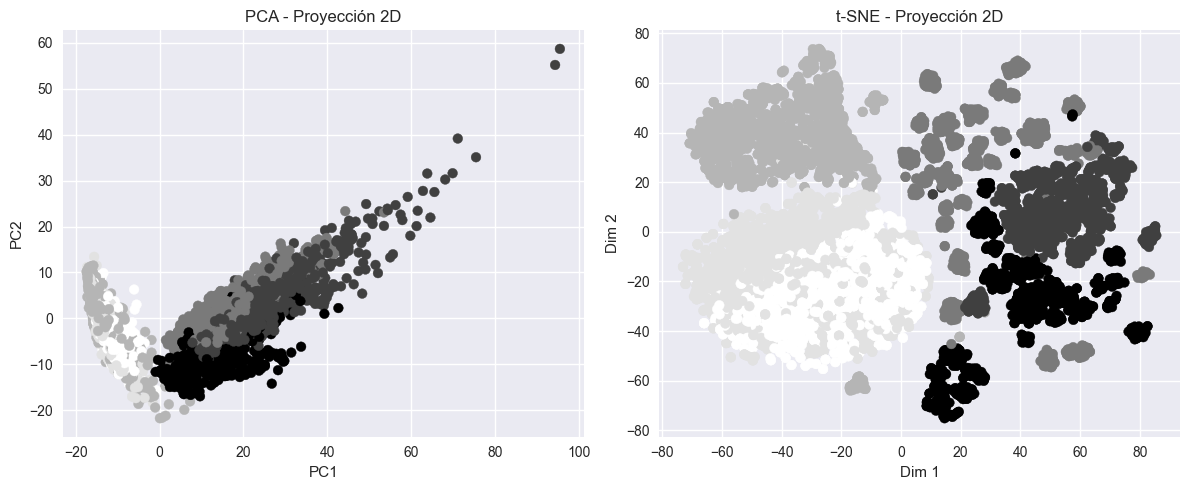

In [30]:
plt.figure(figsize=(12,5))

# PCA
plt.subplot(1,2,1)
plt.scatter(data_pca[:,0], data_pca[:,1], c=pd.factorize(y)[0])
plt.title("PCA - Proyección 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")

# t-SNE
plt.subplot(1,2,2)
plt.scatter(data_tsne[:,0], data_tsne[:,1], c=pd.factorize(y)[0])
plt.title("t-SNE - Proyección 2D")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.tight_layout()
plt.show()

### Comparación entre PCA y t-SNE

Al comparar ambas visualizaciones, se observan diferencias claras en la forma en que cada técnica representa los datos.

En el caso de PCA, la proyección muestra una distribución continua de los datos, donde las distintas actividades no se encuentran claramente separadas. Esto indica que, si bien PCA logra reducir la dimensionalidad preservando la varianza global, no es capaz de capturar estructuras complejas o relaciones no lineales entre las variables.

Por otro lado, t-SNE presenta una separación mucho más clara entre los distintos grupos, formando clusters bien definidos. Esto permite identificar patrones y diferencias entre las observaciones de manera más evidente.

Estas diferencias se deben a que PCA es un método lineal, mientras que t-SNE es un método no lineal que prioriza la preservación de las relaciones locales entre los datos.

En consecuencia, t-SNE resulta más adecuado para la visualización y exploración de patrones, mientras que PCA es más útil como técnica de reducción dimensional en etapas previas al modelado, debido a su eficiencia y capacidad de mantener la estructura global de los datos.

Un cluster corresponde a un conjunto de observaciones que presentan similitudes entre sí y que se encuentran separadas de otros grupos.

En el gráfico de t-SNE, los clusters se consideran bien definidos debido a que los puntos dentro de cada grupo están cercanos entre sí, mientras que existe una separación visible entre distintos grupos, lo que facilita la identificación de patrones en los datos.

## 7. Reflexión

Durante el desarrollo de este análisis se pudo observar la importancia de aplicar técnicas de reducción dimensional cuando se trabaja con datasets de alta complejidad y gran cantidad de variables.

El uso de PCA permitió comprender cómo es posible reducir la dimensionalidad manteniendo la mayor parte de la información relevante, facilitando el procesamiento de los datos y reduciendo el riesgo de sobreajuste en modelos de aprendizaje automático. Además, su interpretación basada en la varianza explicada permite tomar decisiones informadas sobre el número de componentes a utilizar.

Por otro lado, t-SNE demostró ser una herramienta altamente efectiva para la visualización de los datos, logrando revelar patrones y agrupaciones que no son evidentes mediante métodos lineales. Esto resalta la importancia de utilizar técnicas no lineales cuando se busca explorar la estructura interna de los datos.

Una de las principales limitaciones encontradas es que t-SNE tiene un mayor costo computacional y sus resultados pueden variar dependiendo de los parámetros utilizados, lo que dificulta su uso directo en procesos de modelado. Asimismo, las dimensiones generadas por t-SNE no son interpretables, lo que limita su aplicación en contextos donde se requiere explicabilidad.

En conclusión, este análisis demuestra que no existe una única técnica óptima para todos los casos, sino que la elección depende del objetivo del análisis. PCA resulta más adecuado para la reducción dimensional en modelos predictivos, mientras que t-SNE es más útil como herramienta exploratoria y de visualización.

Como trabajo futuro, sería interesante complementar este análisis aplicando técnicas de clustering, como K-Means, sobre los datos reducidos, con el fin de identificar automáticamente grupos en el dataset y profundizar en la segmentación de las observaciones.